#### **1. Introduction: What is Text Splitting?**

*   **Definition:** Text splitting is the process of breaking down a large piece of text (like a PDF, article, or book) into smaller, manageable chunks.
*   **Why is it needed?** Processing a massive document all at once with an LLM is difficult and inefficient. Splitting it into smaller pieces makes it manageable.
*   **What is a Text Splitter?** A tool or component (like in LangChain) that performs this text-splitting operation.

#### **2. Why is Text Splitting Important in Generative AI / RAG?**

There are three main reasons why text splitting is a critical component when building LLM-powered applications, especially for RAG (Retrieval-Augmented Generation):

1.  **Overcomes Model Limitations:**
    *   Every LLM has a **context window limit** (a maximum input size, e.g., 50,000 tokens).
    *   If your document is larger than this limit (e.g., a 100,000-word PDF), you cannot feed it to the model in one go. Text splitting allows you to process the document in parts.

2.  **Improves Downstream Task Performance:**
    *   **For Embeddings:** Generating a single embedding vector for a very long text often fails to capture the semantic meaning accurately. Smaller, focused chunks produce better, more meaningful embeddings.
    *   **For Semantic Search:** Searching for information (like "Which team does Virat Kohli play for?") is more precise when you can compare the query embedding against embeddings of small, topic-specific chunks (e.g., separate chunks for RCB, CSK, MI) rather than one huge document embedding.
    *   **For Summarization:** LLMs tend to perform better and are less prone to hallucinating or drifting off-topic when summarizing smaller, coherent chunks of text rather than one enormous document.

3.  **Optimizes Computational Resources:**
    *   Processing smaller chunks requires less memory.
    *   It allows for better parallelization of tasks, making the overall process faster and more efficient.

#### **3. Types of Text Splitters in LangChain**

The video covers four main types of text splitters, based on different splitting strategies.

##### **B. Text Structure-Based Splitting (Recursive Character Text Splitter)**
*   **Concept:** This is the **most recommended and commonly used** text splitter. It respects the inherent hierarchical structure of text (paragraphs -> sentences -> words -> characters).
*   **How it works (Recursive Algorithm):**
    1.  It attempts to split the text using a list of separators, typically starting with the largest structural unit (e.g., double newline `\n\n` for paragraphs).
    2.  If the resulting chunks are still larger than the `chunk_size`, it moves to the next separator in the list (e.g., single newline `\n` for sentences/lines).
    3.  If those chunks are still too large, it moves to the next separator (e.g., spaces ` ` for words).
    4.  As a final fallback, it splits by individual characters.
    5.  After splitting, it tries to merge small chunks together to optimize size, as long as the merged chunk does not exceed the `chunk_size`.
*   **Pros:**
    *   Creates chunks that are more semantically coherent by trying to keep sentences, paragraphs, and words intact.
    *   Much better than the simple `CharacterTextSplitter` for most text data.

#### **4. Summary & Recommendation**

| Splitter Type | Splitting Basis | Pros | Cons | Use Case |
| :--- | :--- | :--- | :--- | :--- |
| **Length-Based** | Character/Token Count | Very fast, simple | Ignores structure/meaning, can cut sentences/words | When speed is the only priority, or for very simple text. |
| **Text Structure-Based** | Paragraphs -> Sentences -> Words | **Most recommended.** Creates coherent chunks, respects text hierarchy | Slightly slower than length-based | **General-purpose text splitting for most RAG applications.** |
| **Document Structure-Based** | Language-specific syntax (e.g., `class`, `def`, headings) | Preserves logical blocks in code/markdown | Specific to document type | Splitting code files, Markdown docs, HTML. |
| **Semantic-Based** | Change in topic/meaning | Theoretically ideal for semantic coherence | Experimental, can be inaccurate, computationally heavy | Niche cases where topic segmentation is critical. |

**Final Recommendation:** For most projects, the **`RecursiveCharacterTextSplitter`** is your go-to tool. It provides the best balance of coherence, control, and performance.

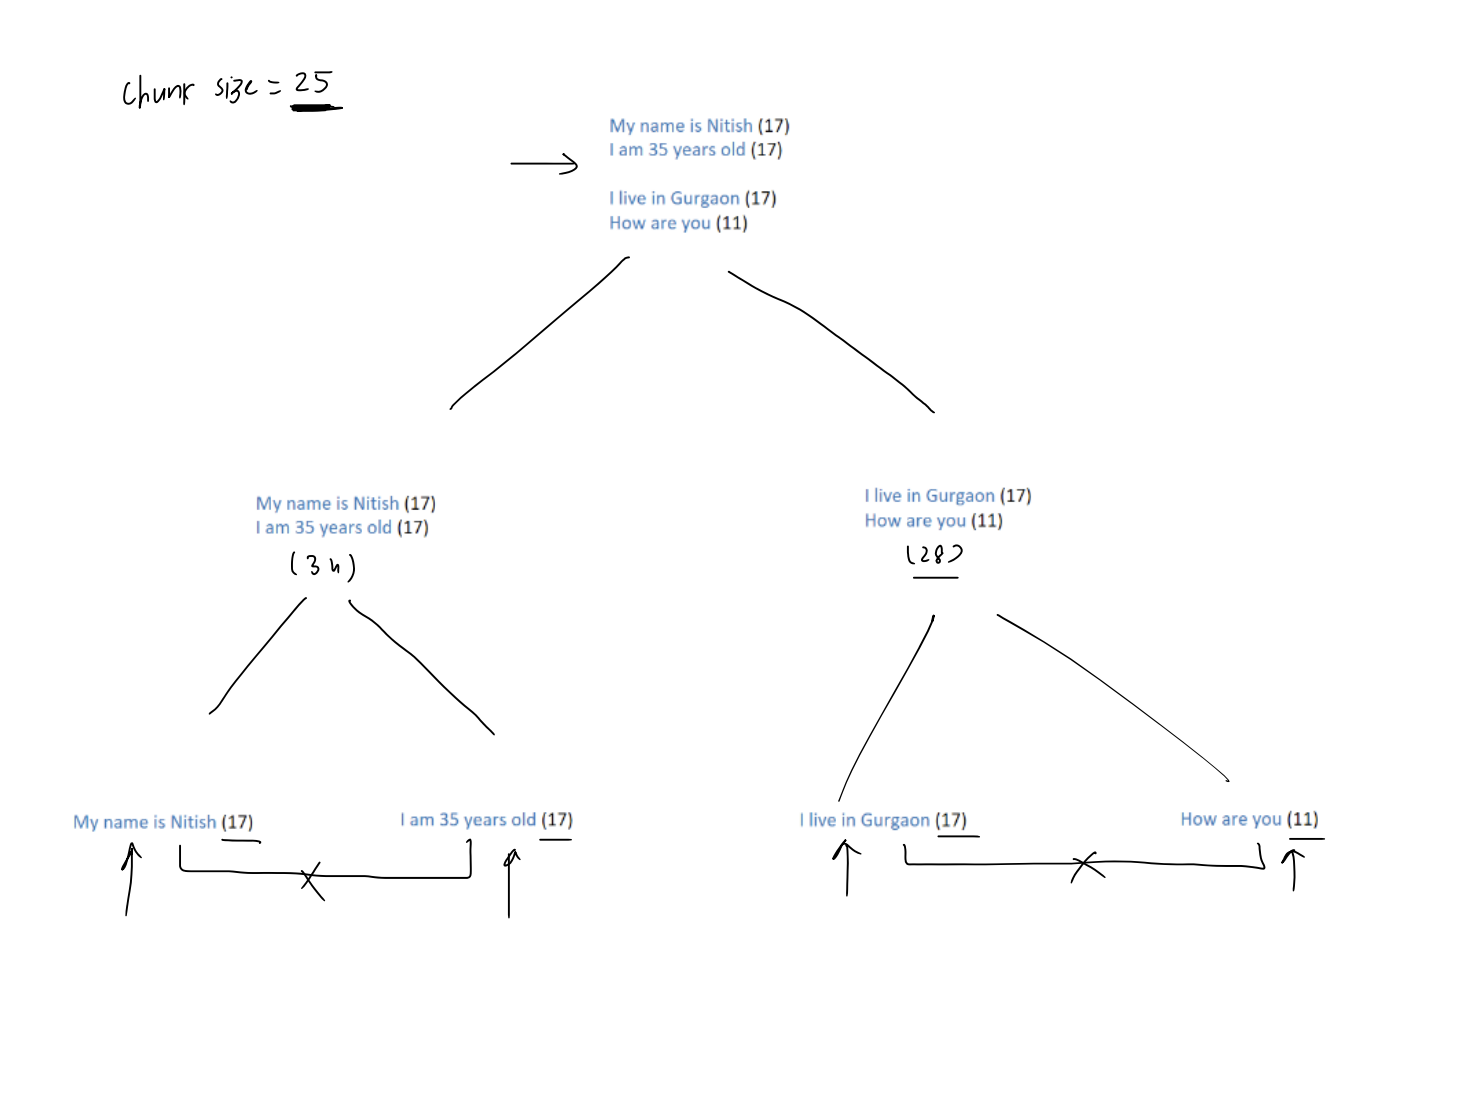

#### Import

In [1]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [2]:
text = """
One of the most important things I didn't understand about the world when I was a child is the degree to which the returns for performance are superlinear.

Teachers and coaches implicitly told us the returns were linear. "You get out," I heard a thousand times, "what you put in." They meant well, but this is rarely true. If your product is only half as good as your competitor's, you don't get half as many customers. You get no customers, and you go out of business.
"""

#### Initialize the splitter

In [5]:
splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

##### perform the split

In [6]:
chunks=splitter.split_text(text)

In [7]:
type(chunks)

list

#### first chunk

In [8]:
chunks[0]

"One of the most important things I didn't understand about the world when I was a child is the"

In [9]:
type(chunks[0])

str